In [ ]:
#!pip install numpy-financial
#!pip install pyxirr

<div class="alert alert-success">
<font color='black'>
    
# Economic Evaluation
  
Probabilistic estimation -> NPV + IRR <br>

</font>
</div>

#### -> Import libraries

In [1]:
import pandas as pd
import openpyxl
import warnings
import numpy_financial as npf
import pyxirr 
from collections import defaultdict       # library to create dictionarie variables
from IPython.display import clear_output  # Clear output cell

warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

import matplotlib.pyplot as plt
import matplotlib
import matplotlib.gridspec as gridspec
import seaborn as sns

import import_ipynb # Library to call costume functions
import Functions_NPV_py as my_Func

#### -> Specify workbook and Sheet
##### -> Workbook must be on the same folder the JN is.

In [2]:
file_name = "00 NPV_py (30 may 26).xlsm"
wb = openpyxl.load_workbook(file_name, data_only=True) # Load the workbook and 
sheet = wb["FFSA"]                                     # Select the sheet

### Import from MS Excel
Production + Capex

In [3]:
Prod_df = my_Func.Import_Range_from_Excel(sheet,"E10:AR17",0)
Prod_df

CAPEX_df = my_Func.Import_Range_from_Excel(sheet,"E20:AR20",0)*-1000000
CAPEX_df

# Copy the first row
new_row = CAPEX_df.loc[0].copy()

# Append to Production DataFrame
Prod_df = pd.concat([Prod_df, new_row.to_frame().T], ignore_index=True)
Prod_df.index = ['year', 'Date', 'Days','BOEs','Gas Prod','Gas Sale','Oil','Gasoline','CAPEX']
Prod_df = Prod_df.transpose()

Prod_df['Date'] = pd.to_datetime(Prod_df['Date'], format='%Y %m %d') # Change Date format
Prod_df

,year,Date,Days,BOEs,Gas Prod,Gas Sale,Oil,Gasoline,CAPEX
0,1,2026-01-01,365,842.359914,4.5875,4.2205,91.75,22.9375,-25500000.0
1,2,2027-01-01,365,4957.758621,27,24.84,540,135,0.0
2,3,2028-01-01,366,4485.96551,24.43061,22.476161,488.612206,122.153051,0.0
3,4,2029-01-01,365,3672.79792,20.002092,18.401925,400.041839,100.01046,0.0
4,5,2030-01-01,365,2720.87562,14.817914,13.632481,296.358283,74.089571,0.0
5,6,2031-01-01,365,1823.857471,9.932745,9.138125,198.654898,49.663725,0.0
6,7,2032-01-01,366,1106.225475,6.024514,5.542553,120.490286,30.122572,0.0
7,8,2033-01-01,365,607.109413,3.306324,3.041818,66.126471,16.531618,0.0
8,9,2034-01-01,365,301.481612,1.641872,1.510522,32.837434,8.209358,0.0
9,10,2035-01-01,365,135.464421,0.737741,0.678721,14.75481,3.688703,0.0


### Delete rows without production

In [4]:
# Iterate from last row to first
element = 0
for index, row in Prod_df.iloc[::-1].iterrows():
    #print(f"Index: {index}, Value: {row['BOEs']}")
    element = element + 1
    #clear_output(wait=True)
    if row['BOEs'] >0:
        LR = index
        break  # Stops the loop completely
print('Rows to delete: ',element)
if element > 2:
    element = element - 2
    Prod_df = Prod_df.iloc[:-element]

pd.set_option('future.no_silent_downcasting', True)
Prod_df = Prod_df.fillna(0)
pd.set_option('future.no_silent_downcasting', False)

#Prod_df['BOEs'] = Prod_df['BOEs'].map('{:,.1f}'.format)
display(Prod_df)

Rows to delete:  30


,year,Date,Days,BOEs,Gas Prod,Gas Sale,Oil,Gasoline,CAPEX
0,1,2026-01-01,365,842.359914,4.5875,4.2205,91.75,22.9375,-25500000.0
1,2,2027-01-01,365,4957.758621,27,24.84,540,135,0.0
2,3,2028-01-01,366,4485.96551,24.43061,22.476161,488.612206,122.153051,0.0
3,4,2029-01-01,365,3672.79792,20.002092,18.401925,400.041839,100.01046,0.0
4,5,2030-01-01,365,2720.87562,14.817914,13.632481,296.358283,74.089571,0.0
5,6,2031-01-01,365,1823.857471,9.932745,9.138125,198.654898,49.663725,0.0
6,7,2032-01-01,366,1106.225475,6.024514,5.542553,120.490286,30.122572,0.0
7,8,2033-01-01,365,607.109413,3.306324,3.041818,66.126471,16.531618,0.0
8,9,2034-01-01,365,301.481612,1.641872,1.510522,32.837434,8.209358,0.0
9,10,2035-01-01,365,135.464421,0.737741,0.678721,14.75481,3.688703,0.0


<div class="alert alert-success"> <font color='black'>
    
# Deterministic Evaluation
    
</font> </div>

In [7]:
Input_var_dict ={}

pd.set_option('display.max_columns', None)  # No column truncation

# -> Import from MS Excel: Prices + Tax + Company Shares, etc.
BTU_scf = sheet["D29"].value
USD_MMBTU = sheet["D30"].value
Oil_Price = sheet["D32"].value
Gov_tax = sheet["D35"].value
Company_Share = sheet["D36"].value
Headco_cost = sheet["D38"].value*1000000
OPEX = sheet["D37"].value
decommissioning = sheet["D26"].value

discount_rate = sheet["D40"].value*0.0100

# -> fill Input dictionary
Input_var_dict['Variable'] = ['Gas Heating Value', 'Gas Price', 'Oil Price','Tax', 'Company Share', 'Headco Cost', 'OPEX', 'Ab','Discount Rate']
Input_var_dict['Value'] = [BTU_scf,USD_MMBTU, Oil_Price,Gov_tax*100,Company_Share*100,Headco_cost/1000000,OPEX,decommissioning, discount_rate*100]
Input_var_dict['Unit'] = ['BTU/scf', 'USD/MMBTU', 'USD/bbl','%','%','MMUSD','USD/bbl','MMUSD', '%']

# -> Calculate Cash Flow 
Cash_Flow_df = pd.DataFrame()
Cash_Flow_df = Prod_df.copy(deep=True)

Cash_Flow_df.loc[:, 'OPEX'] = OPEX  * Cash_Flow_df['BOEs'] * Cash_Flow_df['Days']

Cash_Flow_df.loc[:, 'Ab'] = 0
Cash_Flow_df.iloc[-1, Cash_Flow_df.columns.get_loc('Ab')] = -decommissioning

Cash_Flow_df.loc[:, 'Headco Cost'] = -Headco_cost

Cash_Flow_df.loc[:, 'Gas Price'] = BTU_scf * USD_MMBTU
Cash_Flow_df.loc[:, 'Oil Price'] = Oil_Price

Cash_Flow_df.loc[:, 'Gas Rev'] = Cash_Flow_df['Gas Sale'] * Cash_Flow_df['Gas Price']
Cash_Flow_df.loc[:, 'Liquids Rev'] = (Cash_Flow_df['Oil']+Cash_Flow_df['Gasoline']) * Cash_Flow_df['Oil Price']

Cash_Flow_df.loc[:, 'Total Rev USD_day'] = Cash_Flow_df['Gas Rev']+Cash_Flow_df['Liquids Rev']
Cash_Flow_df.loc[:, 'Total Revenue year'] = Cash_Flow_df['Total Rev USD_day'] * Cash_Flow_df['Days']
Cash_Flow_df.loc[:, 'Tax'] = Cash_Flow_df['Total Revenue year'] * -Gov_tax

Cash_Flow_df.loc[:, 'EBITDA'] = Cash_Flow_df['Total Revenue year'] + Cash_Flow_df['OPEX'] + Cash_Flow_df['CAPEX'] 

Cash_Flow_df.loc[:, 'Operating Cash Flow'] = Cash_Flow_df['EBITDA'] + Cash_Flow_df['Tax'] + Cash_Flow_df['Ab'] 

Cash_Flow_df.loc[:, 'Free Cash Flow'] = Cash_Flow_df['Operating Cash Flow'] + Cash_Flow_df['Ab'] 

pd.set_option('display.float_format', '{:.2f}'.format)

cash_flows_L = Cash_Flow_df['Free Cash Flow'].tolist()

# Calc the NPV
# The function automatically treats cash_flows[0] as Year 0 (undiscounted)
npv_result = npf.npv(discount_rate, cash_flows_L)
print('---------------------------')
print(f"NPV: {npv_result:,.2f} USD") # Display the formatted result

# -> Check if Cash Flow has negative and positive values before IRR is calculated to prevent errors
has_pos = (Cash_Flow_df['Free Cash Flow'] > 0).any()
has_neg = (Cash_Flow_df['Free Cash Flow'] < 0).any()
#print(has_pos)
#print(has_neg)

if has_pos == True and has_neg == True:
    irr = pyxirr.irr(cash_flows_L)                       # Calculate IRR
    #print(irr)
    if irr is None: irr = 0
else:
    irr = 0
        
print(f"IRR: {irr*100:.3f} %")

specific_sum = Cash_Flow_df[['CAPEX', 'Free Cash Flow']].sum()
print('CAPEX: ',specific_sum.get('CAPEX')/1000000, ' MMUSD')



---------------------------
NPV: 55,772,103.47 USD
IRR: 104.105 %
CAPEX:  -25.5  MMUSD


In [8]:
# -> present results
Eco_Val_Results_df = pd.DataFrame(Input_var_dict)

Eco_Val_Results_df['Value'] = Eco_Val_Results_df['Value'].map('{:,.2f}'.format)

display(Eco_Val_Results_df.style.hide(axis="index"))

Cash_Flow_df.head(4)
display(Cash_Flow_df)

Variable,Value,Unit
Gas Heating Value,"1,020.00",BTU/scf
Gas Price,5.68,USD/MMBTU
Oil Price,65.00,USD/bbl
Tax,50.00,%
Company Share,50.00,%
Headco Cost,1.00,MMUSD
OPEX,-5.00,USD/bbl
Ab,2.00,MMUSD
Discount Rate,10.00,%


,year,Date,Days,BOEs,Gas Prod,Gas Sale,Oil,Gasoline,CAPEX,OPEX,Ab,Headco Cost,Gas Price,Oil Price,Gas Rev,Liquids Rev,Total Rev USD_day,Total Revenue year,Tax,EBITDA,Operating Cash Flow,Free Cash Flow
0,1,2026-01-01,365,842.36,4.59,4.22,91.75,22.94,-25500000.00,-1537306.84,0,-1000000,5793.60,65,24451.89,7454.69,31906.58,11645900.35,-5822950.17,-15391406.49,-21214356.67,-21214356.67
1,2,2027-01-01,365,4957.76,27,24.84,540,135,0.00,-9047909.48,0,-1000000,5793.60,65,143913.02,43875,187788.02,68542628.76,-34271314.38,59494719.28,25223404.90,25223404.90
2,3,2028-01-01,366,4485.97,24.43,22.48,488.61,122.15,0.00,-8209316.88,0,-1000000,5793.60,65,130217.89,39699.74,169917.63,62189852.86,-31094926.43,53980535.98,22885609.55,22885609.55
3,4,2029-01-01,365,3672.80,20.00,18.40,400.04,100.01,0.00,-6702856.20,0,-1000000,5793.60,65,106613.39,32503.40,139116.79,50777628.28,-25388814.14,44074772.07,18685957.94,18685957.94
4,5,2030-01-01,365,2720.88,14.82,13.63,296.36,74.09,0.00,-4965598.01,0,-1000000,5793.60,65,78981.14,24079.11,103060.25,37616992.23,-18808496.12,32651394.23,13842898.11,13842898.11
5,6,2031-01-01,365,1823.86,9.93,9.14,198.65,49.66,0.00,-3328539.88,0,-1000000,5793.60,65,52942.64,16140.71,69083.35,25215423.96,-12607711.98,21886884.08,9279172.10,9279172.10
6,7,2032-01-01,366,1106.23,6.02,5.54,120.49,30.12,0.00,-2024392.62,0,-1000000,5793.60,65,32111.34,9789.84,41901.17,15335828.90,-7667914.45,13311436.28,5643521.83,5643521.83
7,8,2033-01-01,365,607.11,3.31,3.04,66.13,16.53,0.00,-1107974.68,0,-1000000,5793.60,65,17623.07,5372.78,22995.85,8393485.50,-4196742.75,7285510.82,3088768.07,3088768.07
8,9,2034-01-01,365,301.48,1.64,1.51,32.84,8.21,0.00,-550203.94,0,-1000000,5793.60,65,8751.36,2668.04,11419.40,4168081.55,-2084040.77,3617877.61,1533836.83,1533836.83
9,10,2035-01-01,365,135.46,0.74,0.68,14.75,3.69,0.00,-247222.57,0,-1000000,5793.60,65,3932.24,1198.83,5131.07,1872839.76,-936419.88,1625617.20,689197.31,689197.31


<div class="alert alert-success"> <font color='black'>
    
# Probabilistic Evaluation
    
</font> </div>
Specify distribution type: Normal, Uniform, Constant.

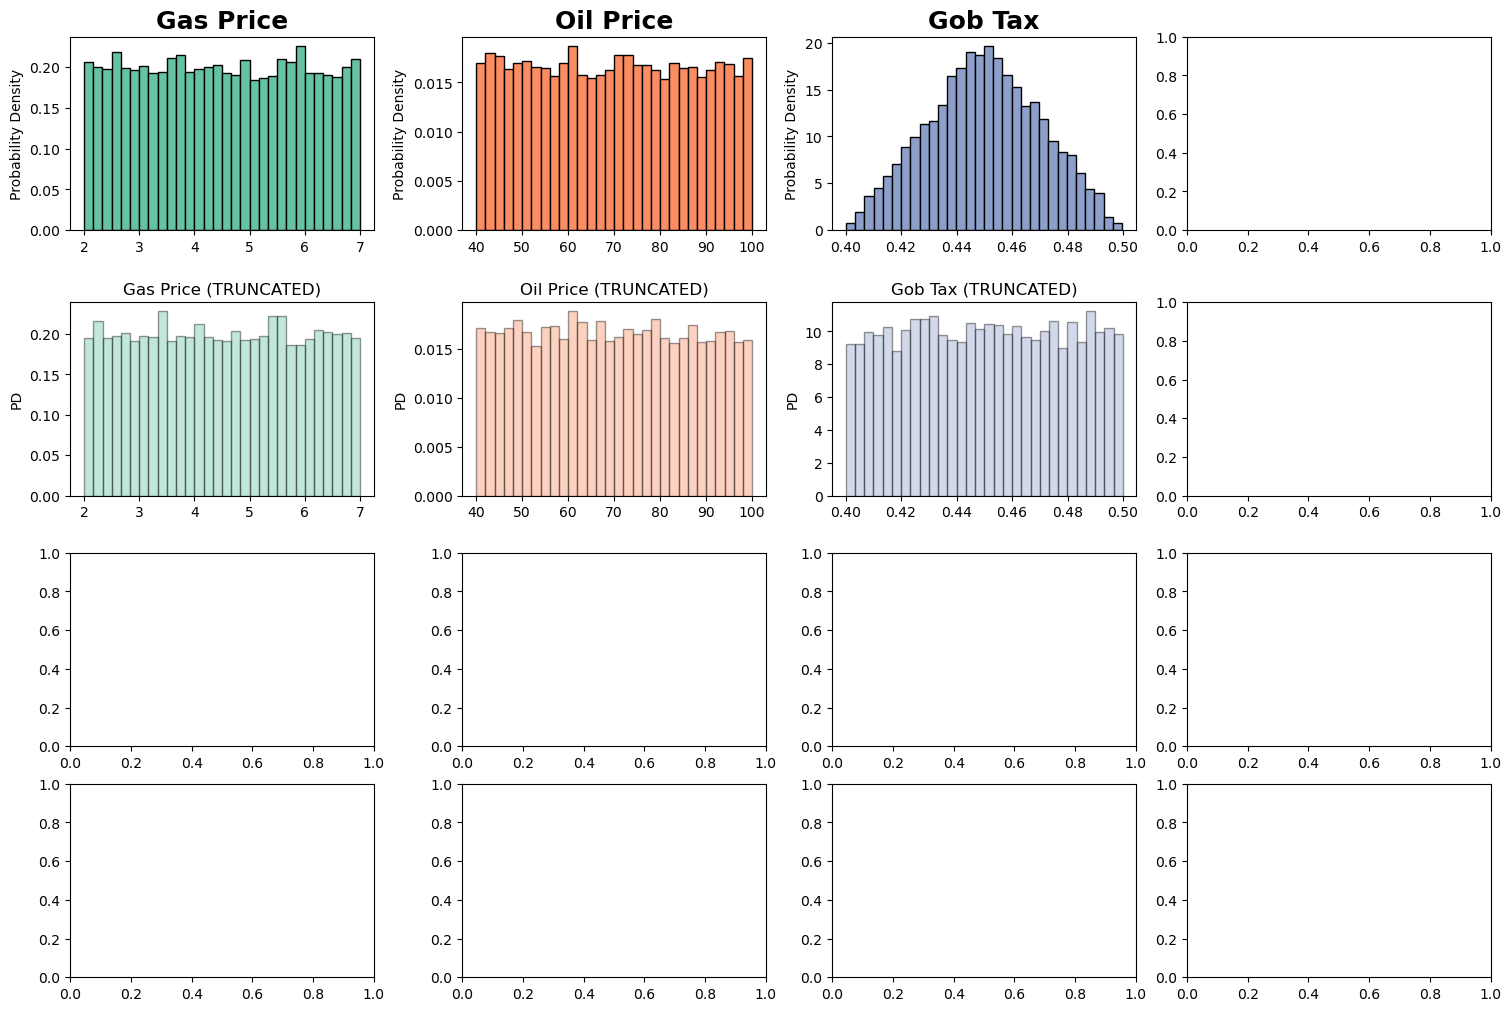

In [9]:
Input_var_dict ={}

var_label, Dist_Type = 'Gas Price','Uniform' 
low, high,val_mean, val_SD, val_Const = 2, 7, 2000, 400, 2500
Input_var_dict['Gas Price'] = [low, high, val_mean, val_SD, val_Const, Dist_Type, var_label]

var_label, Dist_Type = 'Oil Price','Uniform' 
low, high,val_mean, val_SD, val_Const = 40, 100, 2000, 400, 2500
Input_var_dict['Oil Price'] = [low, high, val_mean, val_SD, val_Const, Dist_Type, var_label]

var_label, Dist_Type = 'Gob Tax','Triangular' 
low, high,val_mean, val_SD, val_Const = 0.4, 0.5, 0.45, 400, 2500
Input_var_dict['Gob Tax'] = [low, high, val_mean, val_SD, val_Const, Dist_Type, var_label]


# -> Plot Distributions
my_Func.Plot_Input_func(Input_var_dict)

In [10]:
Input_var_dict

{'Gas Price': [2, 7, 2000, 400, 2500, 'Uniform', 'Gas Price'],
 'Oil Price': [40, 100, 2000, 400, 2500, 'Uniform', 'Oil Price'],
 'Gob Tax': [0.4, 0.5, 0.45, 400, 2500, 'Triangular', 'Gob Tax']}

In [11]:
my_dict, my_dict_input_vals = defaultdict(list), defaultdict(list)  

iteraciones = 1500 # -> Set iterations

i = 0
while i < iteraciones:
    GasPrice, my_dict_input_vals = my_Func.Generate_rand_val('Gas Price',Input_var_dict,my_dict_input_vals)
    OilPrice, my_dict_input_vals = my_Func.Generate_rand_val('Oil Price',Input_var_dict,my_dict_input_vals)
    Gob_Tax, my_dict_input_vals = my_Func.Generate_rand_val('Gob Tax',Input_var_dict,my_dict_input_vals)
    
    print(type(GasPrice))
    npv_result, irr = my_Func.Calc_Eco_Evalv2(Prod_df, GasPrice[0], OilPrice[0],Gob_Tax[0])
    print(irr)
    my_dict_input_vals['NPV'].extend([npv_result/1000000])
    my_dict_input_vals['IRR'].extend([irr])
    
    if i < iteraciones-1:
        clear_output(wait=True)
            
    i = i + 1

<class 'numpy.ndarray'>
1.107535772595013
Gas Price: $5.00
Oil Price: $76.60
---------------------------
Project NPV: $56,593,045.66
Internal Rate of Return: 1.108


,year,Date,Days,BOEs,Gas Prod,Gas Sale,Oil,Gasoline,CAPEX,OPEX,Ab,Headco Cost,Gas Price,Oil Price,Gas Rev,Liquids Rev,Total Rev USD_day,Total Revenue year,Tax,EBITDA,Operating Cash Flow,Free Cash Flow
0,1,2026-01-01,365,842.36,4.59,4.22,91.75,22.94,-25500000.00,-1537306.84,0,-1000000,5250.00,76.60,22157.63,8785.06,30942.69,11294080.94,-5279982.84,-15743225.91,-21023208.74,-21023208.74
1,2,2027-01-01,365,4957.76,27,24.84,540,135,0.00,-9047909.48,0,-1000000,5250.00,76.60,130410.00,51705.00,182115.00,66471975.00,-31075648.31,57424065.52,26348417.20,26348417.20
2,3,2028-01-01,366,4485.97,24.43,22.48,488.61,122.15,0.00,-8209316.88,0,-1000000,5250.00,76.60,117999.85,46784.62,164784.47,60311114.70,-28195446.12,52101797.81,23906351.69,23906351.69
3,4,2029-01-01,365,3672.80,20.00,18.40,400.04,100.01,0.00,-6702856.20,0,-1000000,5250.00,76.60,96610.10,38304.01,134914.11,49243650.24,-23021406.49,42540794.04,19519387.55,19519387.55
4,5,2030-01-01,365,2720.88,14.82,13.63,296.36,74.09,0.00,-4965598.01,0,-1000000,5250.00,76.60,71570.53,28376.31,99946.83,36480593.35,-17054677.39,31514995.35,14460317.95,14460317.95
5,6,2031-01-01,365,1823.86,9.93,9.14,198.65,49.66,0.00,-3328539.88,0,-1000000,5250.00,76.60,47975.16,19021.21,66996.36,24453673.02,-11432092.14,21125133.13,9693041.00,9693041.00
6,7,2032-01-01,366,1106.23,6.02,5.54,120.49,30.12,0.00,-2024392.62,0,-1000000,5250.00,76.60,29098.40,11536.94,40635.35,14872537.78,-6952911.41,12848145.16,5895233.75,5895233.75
7,8,2033-01-01,365,607.11,3.31,3.04,66.13,16.53,0.00,-1107974.68,0,-1000000,5250.00,76.60,15969.54,6331.61,22301.15,8139920.64,-3805412.90,7031945.96,3226533.06,3226533.06
8,9,2034-01-01,365,301.48,1.64,1.51,32.84,8.21,0.00,-550203.94,0,-1000000,5250.00,76.60,7930.24,3144.18,11074.42,4042164.96,-1889712.12,3491961.02,1602248.90,1602248.90
9,10,2035-01-01,365,135.46,0.74,0.68,14.75,3.69,0.00,-247222.57,0,-1000000,5250.00,76.60,3563.29,1412.77,4976.06,1816261.80,-849102.39,1569039.23,719936.84,719936.84


CAPEX            -25500000.00
Free Cash Flow    76641765.61
dtype: object

1.107535772595013


In [12]:
Eco_Eval_df = pd.DataFrame(my_dict_input_vals) # Convert dictionary to DF
Eco_Eval_df.describe()

,Gas Price,Oil Price,Gob Tax,NPV,IRR
count,1500.00,1500.00,1500.00,1500.00,1500.00
mean,4.53,69.95,0.45,49.42,1.00
std,1.41,17.35,0.02,25.40,0.47
min,2.00,40.00,0.40,-5.21,0.00
25%,3.30,54.50,0.44,28.62,0.61
50%,4.60,70.45,0.45,49.73,0.98
75%,5.80,84.10,0.46,69.99,1.36
max,7.00,99.90,0.50,110.80,2.25


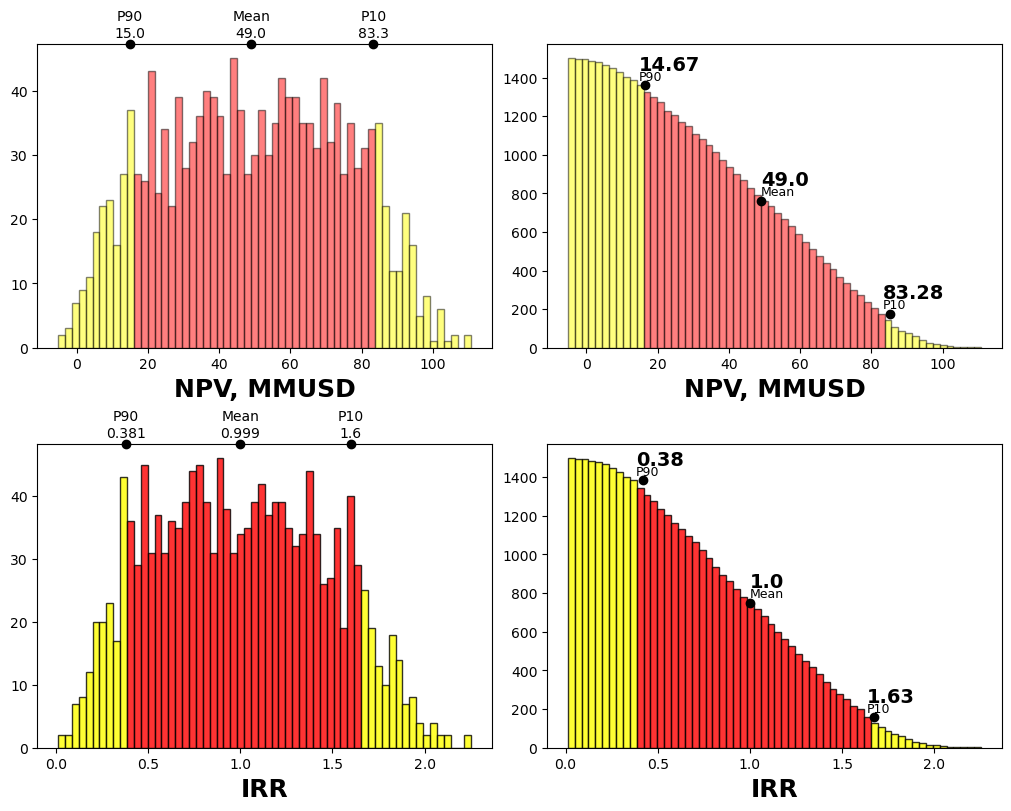

In [13]:
## Plot distributions
fig, ax2 = plt.subplots(nrows = 2, ncols=2, figsize=(10,8), layout ='constrained')

my_Func.Plot_Dist_Cum(Eco_Eval_df['NPV'],0,'NPV, MMUSD',ax2)
my_Func.Plot_Dist_Cum(Eco_Eval_df['IRR'].loc[(Eco_Eval_df['IRR']>0)],1,'IRR',ax2)